# Napredni PyTorch: Konvolucione neuronske mreže (CNN)

Ovaj notebook proširuje osnove sa naprednim konceptima PyTorch-a kroz izgradnju konvolucione neuronske mreže (CNN) za klasifikaciju MNIST slika.

## Postavka
Prvo importujemo potrebne biblioteke i proveravamo dostupan uređaj.

In [1]:
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data.dataloader import default_collate

# Provera dostupnog uređaja: CUDA, zatim MPS, pa CPU
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Korišćeni uređaj: {device}")

Korišćeni uređaj: mps


## Hiperparametri

Definišemo parametre koji kontrolišu treniranje:
- `TRAIN_BATCH_SIZE`: broj primera u svakom trening batch-u.
- `NUM_EPOCHS`: broj prolaza kroz ceo trening skup.
- `lr` (learning rate): stopa učenja za optimizator.
- `WEIGHT_DECAY`: koeficijent L2 regularizacije koja penalizuje velike težine (sprečava preprilagođavanje).

In [2]:
# Hiperparametri treniranja
TRAIN_BATCH_SIZE = 128
NUM_EPOCHS = 5
lr = 1e-3
WEIGHT_DECAY = 1e-4

NUM_CLASSES = 10

print(f"Veličina trening batch-a: {TRAIN_BATCH_SIZE}")
print(f"Broj epoha: {NUM_EPOCHS}")
print(f"Stopa učenja: {lr}")
print(f"L2 Regularizacija: {WEIGHT_DECAY}")

Veličina trening batch-a: 128
Broj epoha: 5
Stopa učenja: 0.001
L2 Regularizacija: 0.0001


## Priprema podataka

Učitavamo MNIST skup podataka i kreiramo data loader-e.

**Custom `collate_fn`:**
- Po podrazumevanom, PyTorch učitava podatke na CPU-u.
- Kreiramo custom funkciju koja prebacuje svaki batch na GPU odmah pri učitavanju, tako da trening petlja ne mora eksplicitno da poziva `.to(device)`.

In [3]:
# Definišemo transformacije za normalizaciju
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Preuzimanje i učitavanje MNIST skupova
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Custom collate funkcija za prebacivanje na GPU
collate_fn = lambda x: tuple(x_.to(device) for x_ in default_collate(x))

# Kreiraj data loader-e
train_loader = DataLoader(train_dataset, batch_size=TRAIN_BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=TRAIN_BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Trening skup: {len(train_dataset)} primera")
print(f"Test skup: {len(test_dataset)} primera")

Trening skup: 60000 primera
Test skup: 10000 primera


## Definicija CNN modela

Kreiramo konvolucionu neuronsku mrežu sa sledećom arhitekturom:

**Slojevi:**
1. `Conv2d(1, 32, kernel_size=3)`: prvi konvolucioni sloj, ulaz 1 kanal (grayscale), izlaz 32 filtera, 3x3 kernel.
2. `Conv2d(32, 64, kernel_size=3)`: drugi konvolucioni sloj, 32 ulaza, 64 filtera.
3. `MaxPool2d(kernel_size=2)`: maksimalno grupisanje sa 2x2 kernelom.
4. `Dropout`: slučajno onemogućava neurone tokom treniranja.
5. `Linear` slojevi: potpuno povezani slojevi na kraju za klasifikaciju.

Transformacija dimenzionalnosti kroz mrežu primer:
- **Ulaz**: (B, 1, 28, 28) - MNIST slike
- **Nakon Conv1**: (B, 32, 26, 26) - jer je kernel=3, padding=0
- **Nakon Conv2**: (B, 64, 24, 24) - ponovo kernel=3, padding=0
- **Nakon MaxPool**: (B, 64, 12, 12) - kernel=2 smanjuje za 2x
- **Nakon flatten**: (B, 9216) - jer je 64 × 12 × 12 = 9216
- **Izlaz**: (B, 10) - 10 klasa za MNIST

In [4]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Konvolucioni slojevi
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        
        # Dropout regularizacija
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        
        # Potpuno povezani slojevi
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, NUM_CLASSES)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        
        x = self.conv2(x)
        x = F.relu(x)
    
        x = F.max_pool2d(x, kernel_size=2)
        x = self.dropout1(x)
        
        x = torch.flatten(x, 1)
        
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        
        return x

# Inicijalizuj model
model = CNN().to(device)
print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## Prilagođena funkcija greške sa regularizacijom

Umesto ugrađene `CrossEntropyLoss`, kreiramo funkciju koja kombinuje:

1. **Softmax Cross-Entropy**: meri razliku između predikcija i tačnih oznaka.
2. **L2 regularizacija**: penalizuje velike težine — sprečava preprilagođavanje.

```
Total Loss = Cross-Entropy + WEIGHT_DECAY × (0.5 × Σ(w²))
```

In [5]:
def loss_fn(logits, labels):
    """Izračunaj gubitak mreže sa L2 regularizacijom."""
    one_hot_labels = F.one_hot(labels, NUM_CLASSES).float()
    cross_entropy = -torch.sum(one_hot_labels * F.log_softmax(logits, dim=1)) / labels.shape[0]
    l2_loss = 0.5 * sum(torch.sum(p ** 2) for p in model.parameters())
    return cross_entropy + WEIGHT_DECAY * l2_loss

## Treniranje modela
Kreiramo dve funkcije:
- `train`: trenira model jednu epohu i vraća prosečan gubitak.
    - `model.train()` - aktivira dropout - neuroni se nasumično isključuju tokom treniranja
- `evaluate`: računa tačnost modela na zadatom data loader-u.
    - `model.eval()` - deaktivira dropout - svi neuroni aktivni, deterministične predikcije

In [6]:
def train(model, loader, optimizer):
    model.train()
    epoch_loss = 0.0
    for images, labels in loader:
        logits = model(images)
        loss = loss_fn(logits, labels)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        epoch_loss += loss.item()
    return epoch_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in loader:
            predictions = model(images)
            correct += (torch.argmax(predictions, dim=1) == labels).sum().item()
    return correct / len(loader.dataset)

In [7]:
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

test_accuracies = []
epoch_losses = []

for epoch in range(NUM_EPOCHS):
    avg_loss = train(model, train_loader, optimizer)
    test_acc = evaluate(model, test_loader)

    test_accuracies.append(test_acc)
    epoch_losses.append(avg_loss)
    print(f"Epoha {epoch+1:2d}/{NUM_EPOCHS} | Gubitak: {avg_loss:.4f} | Test tačnost: {test_acc:.4f}")

Epoha  1/5 | Gubitak: 0.2755 | Test tačnost: 0.9813
Epoha  2/5 | Gubitak: 0.1146 | Test tačnost: 0.9846
Epoha  3/5 | Gubitak: 0.1030 | Test tačnost: 0.9865
Epoha  4/5 | Gubitak: 0.0930 | Test tačnost: 0.9883
Epoha  5/5 | Gubitak: 0.0924 | Test tačnost: 0.9894


## Vizuelizacija rezultata

Crtamo dva grafikona:
1. **Gubitak tokom epoha**: pokazuje kako se gubitak smanjuje tokom treniranja.
2. **Test tačnost tokom epoha**: pokazuje kako se tačnost poboljšava.

Ovi grafikoni nam pomažu da razumemo performanse modela i da identifikujemo:
- Da li se model dobro obučava (trend padajućeg gubitka).
- Postoji li preprilagođavanje (divergencija između trening i test metrika).

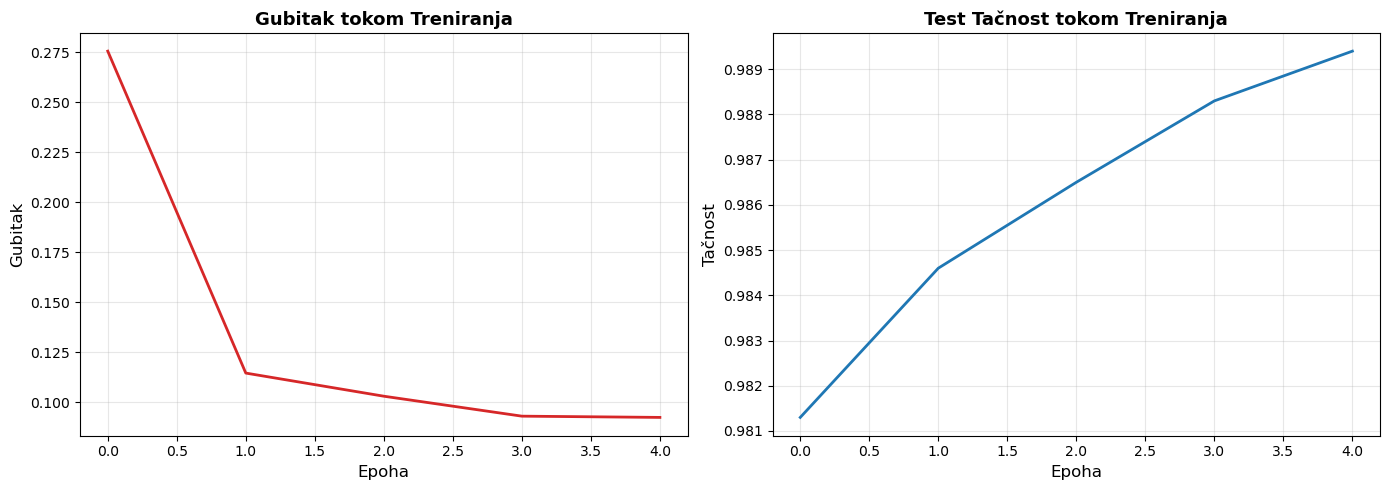

In [9]:
# Vizuelizacija
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafik gubitka
axes[0].plot(epoch_losses, linewidth=2, color='tab:red')
axes[0].set_xlabel('Epoha', fontsize=12)
axes[0].set_ylabel('Gubitak', fontsize=12)
axes[0].set_title('Gubitak tokom Treniranja', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Grafik tačnosti
axes[1].plot(test_accuracies, linewidth=2, color='tab:blue')
axes[1].set_xlabel('Epoha', fontsize=12)
axes[1].set_ylabel('Tačnost', fontsize=12)
axes[1].set_title('Test Tačnost tokom Treniranja', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Zaključak

U ovom notebook-u smo naučili:

1. **Konvolucione neuronske mreže (CNN)**: kako koriste konvolucionе slojeve za ekstraktovanje obeležja iz slika.
2. **Napredne PyTorch funkcije**: `torch.nn.functional` za fleksibilne operacije, custom loss funkcije, regularizaciju.
3. **Razdvojeni trening i evaluacioni režimi**: `model.train()` i `model.eval()` su bitni za dropout i batch normalizaciju.
4. **Optimizacija sa regularizacijom**: L2 regularizacija (weight decay) sprečava preprilagođavanje.
5. **Vizuelizacija rezultata**: grafikoni nam pomažu da razumemo tok treniranja.

Ove tehnike su fundamentalne za rad sa kompleksnijim modelima u proizvodnji!

Ovaj notebook je prilagođen na osnovu materijala [EEML 2025](https://github.com/eemlcommunity/PracticalSessions2025) . Copyright (c) 2025 EEML.